In [1]:
from google.colab import files
uploaded = files.upload()
print(list(uploaded.keys()))

Saving IoT_Traffic_Dataset.csv to IoT_Traffic_Dataset.csv
['IoT_Traffic_Dataset.csv']


# **Section 1 — Imports**

In [2]:
import io                          # For reading files from memory
import pandas as pd                # For data manipulation
import numpy as np                 # For numerical operations
import matplotlib.pyplot as plt    # For plotting charts
import seaborn as sns              # For enhanced visualizations

from sklearn.model_selection import train_test_split, cross_val_score  # Split data & cross-validation
from sklearn.preprocessing import StandardScaler                        # For feature scaling
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay) # Evaluation metrics
from sklearn.linear_model import LogisticRegression                     # Logistic Regression model
from sklearn.tree import DecisionTreeClassifier                         # Decision Tree model
from sklearn.ensemble import RandomForestClassifier                     # Random Forest model

# **Section 2 — Data Loading & Exploration**

In [3]:
# Read the uploaded file regardless of its name
filename = list(uploaded.keys())[0]                  # Get the first uploaded file name
df = pd.read_csv(io.BytesIO(uploaded[filename]))     # Load it as a CSV into a DataFrame

print(df.head())                                     # Show first 5 rows
print(df.info())                                     # Show column types and info
print(df.isnull().sum())                             # Count missing values per column
print(df['Congestion_Level'].value_counts())         # Show class distribution of target

    Latitude  Longitude  Traffic_Speed_kmph  Traffic_Density_vpkm  \
0  12.917964  77.623311           55.190066             41.483270   
1  13.088692  77.567956           52.085809             31.007323   
2  13.066659  77.660855           37.627867             30.668128   
3  13.036142  77.617962           28.233521             29.649618   
4  13.082460  77.577661           22.363697             39.744264   

   FFT_Feature_1  FFT_Feature_2  FFT_Feature_3  Vehicle_Count  \
0       0.185443       0.838712       0.647059             17   
1       0.069059       0.176809       0.758469             20   
2       0.264561       0.339073       0.074449             16   
3       0.412920       0.286254       0.241308             16   
4       0.306188       0.356061       0.769289             29   

   Time_of_Day_min  Congestion_Level  
0              852                 0  
1             1048                 0  
2               73                 1  
3              209                 1  

# **Section 3 — Exploratory Visualization**

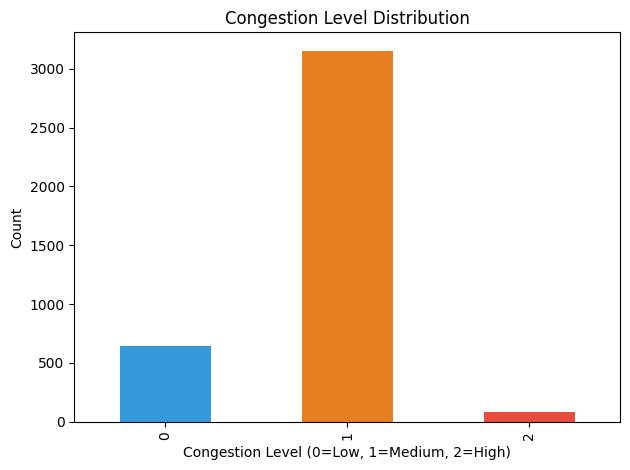

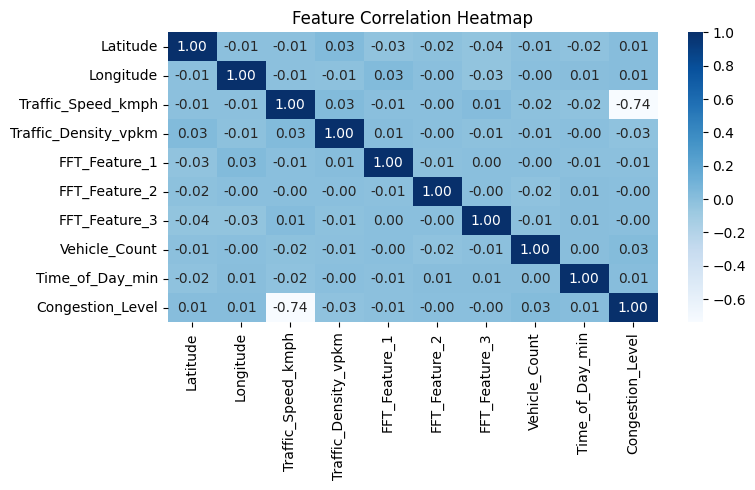

In [4]:
# Bar chart for congestion level distribution
df['Congestion_Level'].value_counts().sort_index().plot(
    kind='bar', color=['#3498db', '#e67e22', '#e74c3c'])  # Different color per class
plt.title('Congestion Level Distribution')                 # Chart title
plt.xlabel('Congestion Level (0=Low, 1=Medium, 2=High)')  # X-axis label
plt.ylabel('Count')                                        # Y-axis label
plt.tight_layout()                                         # Adjust layout spacing
plt.show()                                                 # Display the chart

# Heatmap for feature correlations
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='Blues')  # Annotated correlation heatmap
plt.title('Feature Correlation Heatmap')                      # Chart title
plt.tight_layout()
plt.show()

# **Section 4 — Preprocessing**

In [5]:
df = df.dropna()                   # Remove rows with missing values

# Define features and target
X = df.drop(['Congestion_Level',
             'Traffic_Speed_kmph',
             'Traffic_Density_vpkm',
             'Vehicle_Count'], axis=1)   # Drop target and leakage columns
y = df['Congestion_Level']               # Target variable

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)  # 80/20 split, stratified

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit on train, transform train
X_test_scaled  = scaler.transform(X_test)        # Transform test only (no fit)

# **Section 5 — Model Training**

In [6]:
# Train Logistic Regression (uses scaled data)
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Train Decision Tree (uses raw data)
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)

# Train Random Forest (uses raw data)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# **Section 6 — Evaluation**

In [8]:
# Generate predictions for each model
lr_pred = lr_model.predict(X_test_scaled)   # Logistic Regression predictions
dt_pred = dt_model.predict(X_test)          # Decision Tree predictions
rf_pred = rf_model.predict(X_test)          # Random Forest predictions

# Calculate accuracy for each model
lr_acc = accuracy_score(y_test, lr_pred)
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", round(lr_acc, 4))
print("Decision Tree Accuracy:      ", round(dt_acc, 4))
print("Random Forest Accuracy:      ", round(rf_acc, 4))

# Print detailed classification report for each model
for pred, name in zip(
    [lr_pred, dt_pred, rf_pred],
    ['Logistic Regression', 'Decision Tree', 'Random Forest']):
    print(f"\n--- {name} ---")
    print(classification_report(y_test, pred,
                                 target_names=['Low', 'Medium', 'High'],
                                 zero_division=0))  # Avoid division by zero warnings

# Cross-validation scores (5-fold)
lr_cv = cross_val_score(lr_model, X_train_scaled, y_train, cv=5).mean()
dt_cv = cross_val_score(dt_model, X_train,        y_train, cv=5).mean()
rf_cv = cross_val_score(rf_model, X_train,        y_train, cv=5).mean()

print("Logistic Regression CV:", round(lr_cv, 4))
print("Decision Tree CV:      ", round(dt_cv, 4))
print("Random Forest CV:      ", round(rf_cv, 4))

Logistic Regression Accuracy: 0.299
Decision Tree Accuracy:       0.6727
Random Forest Accuracy:       0.8119

--- Logistic Regression ---
              precision    recall  f1-score   support

         Low       0.15      0.24      0.19       129
      Medium       0.80      0.31      0.45       631
        High       0.01      0.25      0.02        16

    accuracy                           0.30       776
   macro avg       0.32      0.27      0.22       776
weighted avg       0.68      0.30      0.40       776


--- Decision Tree ---
              precision    recall  f1-score   support

         Low       0.18      0.20      0.19       129
      Medium       0.81      0.78      0.80       631
        High       0.05      0.06      0.05        16

    accuracy                           0.67       776
   macro avg       0.35      0.35      0.35       776
weighted avg       0.69      0.67      0.68       776


--- Random Forest ---
              precision    recall  f1-score   support

# **Section 7 — Model Comparison Charts**

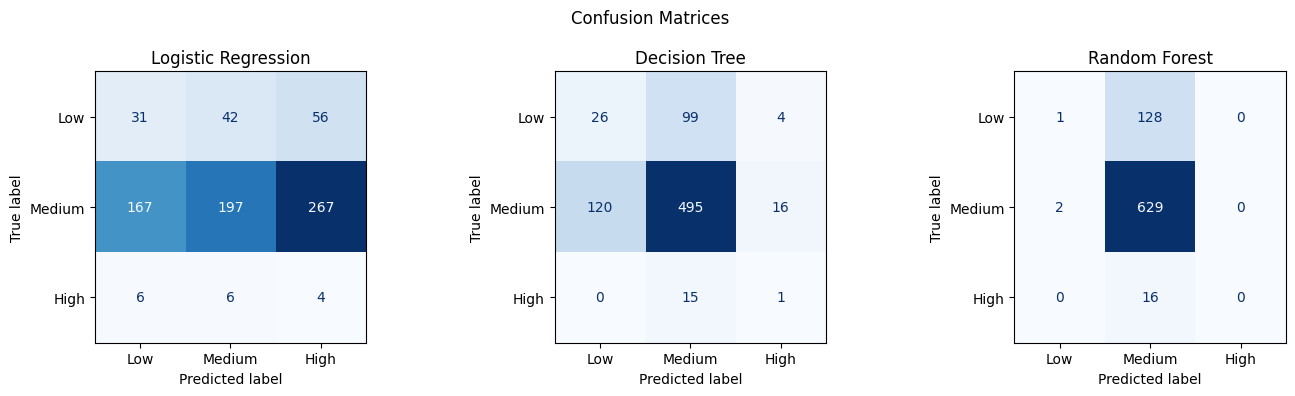

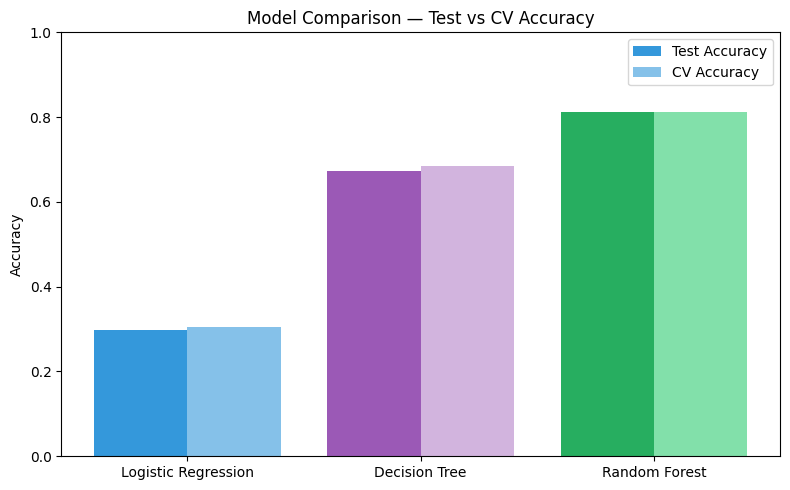

In [9]:
# Plot confusion matrix for each model side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for pred, name, ax in zip(
    [lr_pred, dt_pred, rf_pred],
    ['Logistic Regression', 'Decision Tree', 'Random Forest'], axes):
    cm = confusion_matrix(y_test, pred)                              # Compute confusion matrix
    ConfusionMatrixDisplay(cm, display_labels=['Low', 'Medium', 'High']).plot(
        ax=ax, cmap='Blues', colorbar=False)                         # Plot it
    ax.set_title(name)
plt.suptitle('Confusion Matrices')
plt.tight_layout()
plt.show()

# Bar chart comparing Test vs CV accuracy for all models
models   = ['Logistic Regression', 'Decision Tree', 'Random Forest']
test_acc = [lr_acc, dt_acc, rf_acc]
cv_acc   = [lr_cv,  dt_cv,  rf_cv]

x = np.arange(len(models))
plt.figure(figsize=(8, 5))
plt.bar(x - 0.2, test_acc, 0.4, label='Test Accuracy',       # Test accuracy bars
        color=['#3498db', '#9b59b6', '#27ae60'])
plt.bar(x + 0.2, cv_acc,   0.4, label='CV Accuracy',         # CV accuracy bars
        color=['#85c1e9', '#d2b4de', '#82e0aa'])
plt.xticks(x, models)
plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Comparison — Test vs CV Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# **Section 8 — Best Model**

In [10]:
best_idx = np.argmax(test_acc)    # Index of the highest test accuracy
best     = models[best_idx]       # Name of the best model

print(f"\nBest Model: {best}")
print(f"Test Accuracy: {round(test_acc[best_idx] * 100, 2)}%")
print(f"CV Accuracy:   {round(cv_acc[best_idx]  * 100, 2)}%")


Best Model: Random Forest
Test Accuracy: 81.19%
CV Accuracy:   81.16%
